In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_data():
    df = pd.read_csv('ecommerce_data.csv')

    # Convert to NumPy arrays
    data = df.to_numpy()

    # Shuffle the data
    np.random.shuffle(data)

    # Split into input (X) and output (y)
    X = data[:, :-1]
    y = data[:, -1].astype(np.int32)

    N, D = X.shape
    X2 = np.zeros((N, D + 3))  # Add a column of ones for bias
    X2[:, :(D-1)] = X[:, :(D-1)] # Non-categorical columns

    # One-hot encode the categorical data
    # Method 1
    # for n in range(N):
    #     t = int(X[n, D-1])
    #     X2[n, t+D-1] = 1

    # Method 2 - More efficient
    Z = np.zeros((N, 4))
    Z[np.arange(N), X[:, D-1].astype(np.int32)] = 1
    X2[:,-4:] = Z
    X = X2

    # Split train and test data
    Xtrain = X[:-100]
    Ytrain = y[:-100]
    Xtest = X[-100:]
    Ytest = y[-100:]

    # Standardize the data - columns 1 and 2
    for i in (1, 2):
        mean_ = Xtrain[:,i].mean()
        std_ = Xtrain[:,i].std()
        Xtrain[:,i] = (Xtrain[:,i] - mean_) / std_
        Xtest[:,i] = (Xtest[:,i] - mean_) / std_

    return Xtrain, Ytrain, Xtest, Ytest


In [3]:
# One-Hot encode the categorical data (y)
def y2indicator(y, K):
    N = len(y)
    ind = np.zeros((N, K))
    for i in range(N):
        ind[i, y[i]] = 1
    return ind

In [4]:
# Get data
Xtrain, Ytrain, Xtest, Ytest = get_data()

In [5]:
D = Xtrain.shape[1]
K = len(set(Ytrain) | set(Ytest))

In [6]:
# Convert to indicator
Ytrain_ind = y2indicator(Ytrain, K)
Ytest_ind = y2indicator(Ytest, K)

In [7]:
# Randomly initialize weights
W = np.random.randn(D, K) / np.sqrt(D)
b = np.zeros(K)

In [8]:
# Define sigmoid function
def softmax(a):
    a -= np.max(a, axis=1, keepdims=True)  # for numerical stability
    expA = np.exp(a)
    A = expA / expA.sum(axis=1, keepdims=True)
    return A

In [9]:
# Define forward propagation
def forward_pass(X, W, b):
    """
    Perform the forward pass of a neural network.

    Parameters:
    X : ndarray
        Input data matrix where each row is a sample and each column is a feature.
    W : ndarray
        Weight matrix for the connections between layers.
    b : ndarray
        Bias vector added to the weighted sum of inputs.

    Returns:
    tuple
        A tuple containing:
        - A2 : ndarray
            The output of the softmax function, representing the predicted probabilities for each class.
        - A1 : ndarray
            The output of the sigmoid function, representing the activations of the hidden layer.
    """
    Z = X.dot(W) + b
    A = softmax(Z)
    return A

In [10]:
# Define the predict function
def predict(p_Y_given_X):
    return np.argmax(p_Y_given_X, axis=1)

In [11]:
# Define classification rate
def classification_rate(Y, P):
    return np.mean(Y == P)

In [12]:
# Define the cross-entropy cost function
def cross_entropy(Y, pY):
    return -np.sum(Y * np.log(pY)) / len(Y)

In [13]:
train_loss = []
test_loss = []
learning_rate = 0.2
epochs = 15_000

for epoch in range(epochs):
    p_Y_given_X = forward_pass(Xtrain, W, b)
    p_Y_test_given_X = forward_pass(Xtest, W, b)

    ce_train = cross_entropy(Ytrain_ind, p_Y_given_X)
    ce_test = cross_entropy(Ytest_ind, p_Y_test_given_X)

    train_loss.append(ce_train)
    test_loss.append(ce_test)
    
    # Update weights and bias using gradient descent
    dW = (Xtrain.T.dot(p_Y_given_X - Ytrain_ind)) / len(Ytrain)
    db = (p_Y_given_X - Ytrain_ind).sum(axis=0) / len(Ytrain)
    W -= learning_rate * dW
    b -= learning_rate * db

    if epoch % 1_000 == 0 or epoch == epochs - 1:
        print(f'Epoch: {epoch}         Train loss: {ce_train:.4f}       Test loss: {ce_test:.4f}')

Epoch: 0         Train loss: 1.5204       Test loss: 1.5289
Epoch: 1000         Train loss: 0.3827       Test loss: 0.3779
Epoch: 2000         Train loss: 0.3593       Test loss: 0.3487
Epoch: 3000         Train loss: 0.3494       Test loss: 0.3352
Epoch: 4000         Train loss: 0.3440       Test loss: 0.3276
Epoch: 5000         Train loss: 0.3407       Test loss: 0.3227
Epoch: 6000         Train loss: 0.3384       Test loss: 0.3195
Epoch: 7000         Train loss: 0.3368       Test loss: 0.3173
Epoch: 8000         Train loss: 0.3356       Test loss: 0.3156
Epoch: 9000         Train loss: 0.3347       Test loss: 0.3144
Epoch: 10000         Train loss: 0.3339       Test loss: 0.3134
Epoch: 11000         Train loss: 0.3334       Test loss: 0.3127
Epoch: 12000         Train loss: 0.3329       Test loss: 0.3121
Epoch: 13000         Train loss: 0.3325       Test loss: 0.3117
Epoch: 14000         Train loss: 0.3322       Test loss: 0.3113
Epoch: 14999         Train loss: 0.3319       Test lo

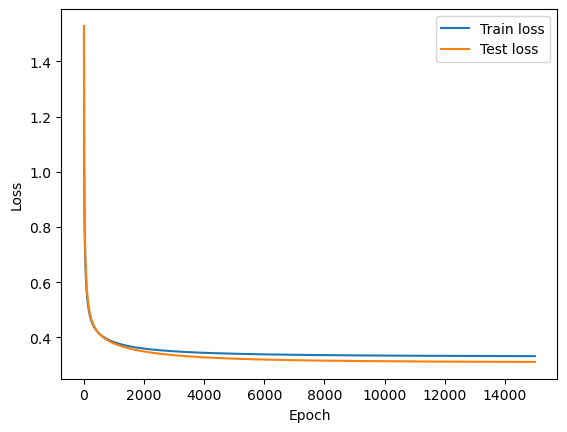

In [14]:
# Plot the loss curve
plt.plot(train_loss, label='Train loss')
plt.plot(test_loss, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
# Evaluate the model on the train and test sets
Ytrain_pred = predict(p_Y_given_X)
accuracy_train = classification_rate(Ytrain, Ytrain_pred)
print(f'Classification rate (train set): {accuracy_train * 100:.3f}% accuracy')

Ytest_pred = predict(p_Y_test_given_X)
accuracy_test = classification_rate(Ytest, Ytest_pred)
print(f'Classification rate (test set): {accuracy_test * 100:.3f}% accuracy')

Classification rate (train set): 90.250% accuracy
Classification rate (test set): 95.000% accuracy
